In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
df = pd.read_csv("qr_fraud_detection_dataset_10000.csv")

print(df.head())
print(df.shape)

   URL_Length  HTTPS Domain_Extension  Contains_Login  Contains_Verification  \
0          29      1              com               0                      0   
1          46      1               in               0                      0   
2          25      1              net               0                      0   
3          30      1              org               1                      0   
4          56      1              org               0                      1   

   Contains_Brand  Domain_Age_Days  Blacklisted  Fraud  
0               1             1172            0      1  
1               1             1795            0      1  
2               0             2327            0      1  
3               1             1665            0      1  
4               1              657            0      1  
(10000, 9)


In [3]:
print(df.isnull().sum())

URL_Length               0
HTTPS                    0
Domain_Extension         0
Contains_Login           0
Contains_Verification    0
Contains_Brand           0
Domain_Age_Days          0
Blacklisted              0
Fraud                    0
dtype: int64


In [4]:
print(df.isnull().sum())

URL_Length               0
HTTPS                    0
Domain_Extension         0
Contains_Login           0
Contains_Verification    0
Contains_Brand           0
Domain_Age_Days          0
Blacklisted              0
Fraud                    0
dtype: int64


In [5]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df.shape)

Duplicate Rows: 25
Shape After Removing Duplicates: (9975, 9)


In [6]:
print(df.dtypes)

URL_Length                int64
HTTPS                     int64
Domain_Extension         object
Contains_Login            int64
Contains_Verification     int64
Contains_Brand            int64
Domain_Age_Days           int64
Blacklisted               int64
Fraud                     int64
dtype: object


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 9975 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   URL_Length             9975 non-null   int64 
 1   HTTPS                  9975 non-null   int64 
 2   Domain_Extension       9975 non-null   object
 3   Contains_Login         9975 non-null   int64 
 4   Contains_Verification  9975 non-null   int64 
 5   Contains_Brand         9975 non-null   int64 
 6   Domain_Age_Days        9975 non-null   int64 
 7   Blacklisted            9975 non-null   int64 
 8   Fraud                  9975 non-null   int64 
dtypes: int64(8), object(1)
memory usage: 779.3+ KB
None


In [8]:
print(df.describe())

        URL_Length        HTTPS  Contains_Login  Contains_Verification  \
count  9975.000000  9975.000000     9975.000000            9975.000000   
mean     51.578346     0.897343        0.136241               0.111980   
std      25.055888     0.303525        0.343061               0.315358   
min      20.000000     0.000000        0.000000               0.000000   
25%      34.000000     1.000000        0.000000               0.000000   
50%      48.000000     1.000000        0.000000               0.000000   
75%      62.000000     1.000000        0.000000               0.000000   
max     150.000000     1.000000        1.000000               1.000000   

       Contains_Brand  Domain_Age_Days  Blacklisted        Fraud  
count     9975.000000      9975.000000  9975.000000  9975.000000  
mean         0.642506      2406.668672     0.094937     0.899950  
std          0.479286      1486.794507     0.293143     0.300082  
min          0.000000         1.000000     0.000000     0.000000 

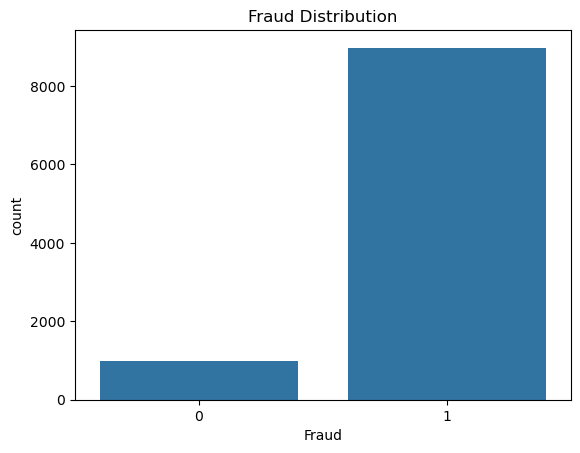

In [9]:
sns.countplot(x='Fraud', data=df)
plt.title("Fraud Distribution")
plt.show()

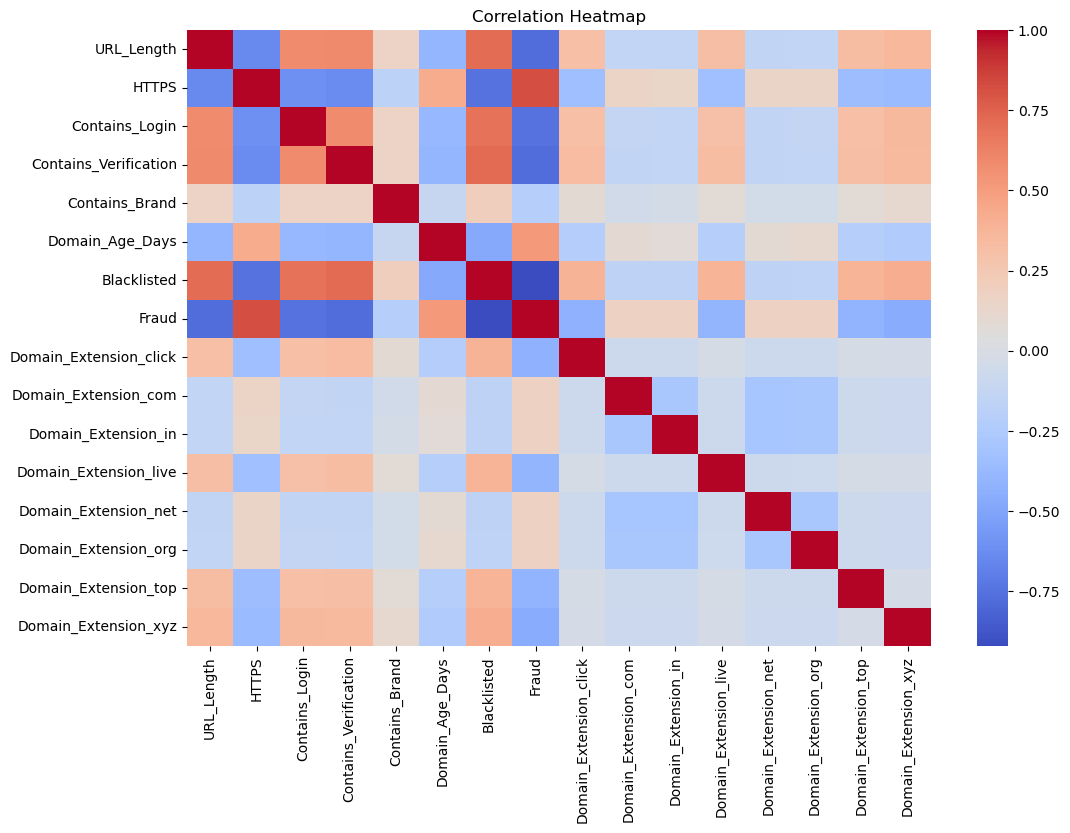

In [10]:
temp_df = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12,8))
sns.heatmap(temp_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

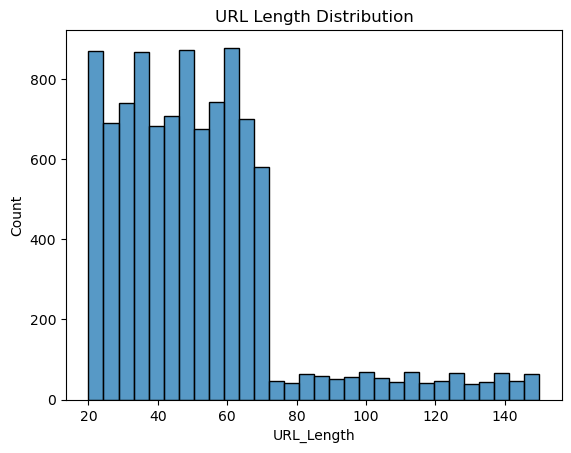

In [11]:
sns.histplot(df['URL_Length'], bins=30)
plt.title("URL Length Distribution")
plt.show()

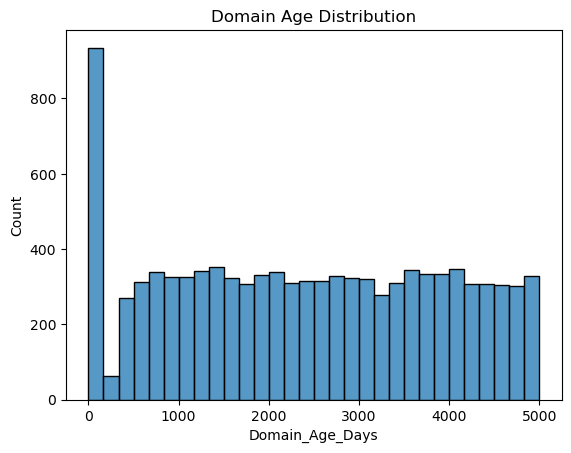

In [12]:
sns.histplot(df['Domain_Age_Days'], bins=30)
plt.title("Domain Age Distribution")
plt.show()

In [16]:
print(df.head())

   URL_Length  HTTPS  Contains_Login  Contains_Verification  Contains_Brand  \
0          29      1               0                      0               1   
1          46      1               0                      0               1   
2          25      1               0                      0               0   
3          30      1               1                      0               1   
4          56      1               0                      1               1   

   Domain_Age_Days  Blacklisted  Fraud  Domain_Extension_click  \
0             1172            0      1                   False   
1             1795            0      1                   False   
2             2327            0      1                   False   
3             1665            0      1                   False   
4              657            0      1                   False   

   Domain_Extension_com  Domain_Extension_in  Domain_Extension_live  \
0                  True                False             

In [19]:
x= df.drop('Fraud', axis=1)

y = df['Fraud']

In [20]:
print(x.shape)
print(y.shape)

(9975, 15)
(9975,)


In [22]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(x_train.shape)
print(x_test.shape)

(7980, 15)
(1995, 15)


In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
y_pred = rf_model.predict(x_test)

y_prob = rf_model.predict_proba(x_test)[:,1]

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [26]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 1.0


In [27]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 1.0


In [28]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 1.0


In [29]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 1.0


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00      1795

    accuracy                           1.00      1995
   macro avg       1.00      1.00      1.00      1995
weighted avg       1.00      1.00      1.00      1995



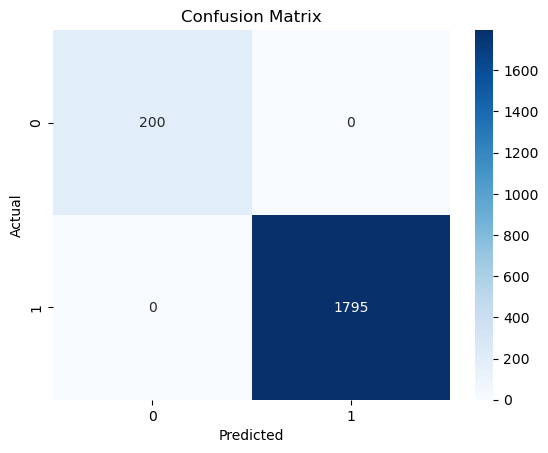

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [32]:
param_grid = {

    'n_estimators':[100,200,300],

    'max_depth':[5,10,15,None],

    'min_samples_split':[2,5,10],

    'min_samples_leaf':[1,2,4]

}

In [33]:
grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring='f1',

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [34]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [35]:
best_rf = grid_search.best_estimator_

In [36]:
y_pred_tuned = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_tuned)

f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Accuracy:", accuracy)

print("Tuned F1 Score:", f1)

Tuned Accuracy: 1.0
Tuned F1 Score: 1.0


In [37]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': best_rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                   Feature  Importance
5          Domain_Age_Days    0.265282
0               URL_Length    0.228799
6              Blacklisted    0.143053
1                    HTTPS    0.126163
2           Contains_Login    0.088155
3    Contains_Verification    0.083584
14    Domain_Extension_xyz    0.021019
13    Domain_Extension_top    0.009303
7   Domain_Extension_click    0.008736
10   Domain_Extension_live    0.006922
12    Domain_Extension_org    0.004756
8     Domain_Extension_com    0.004128
9      Domain_Extension_in    0.004056
4           Contains_Brand    0.003071
11    Domain_Extension_net    0.002974


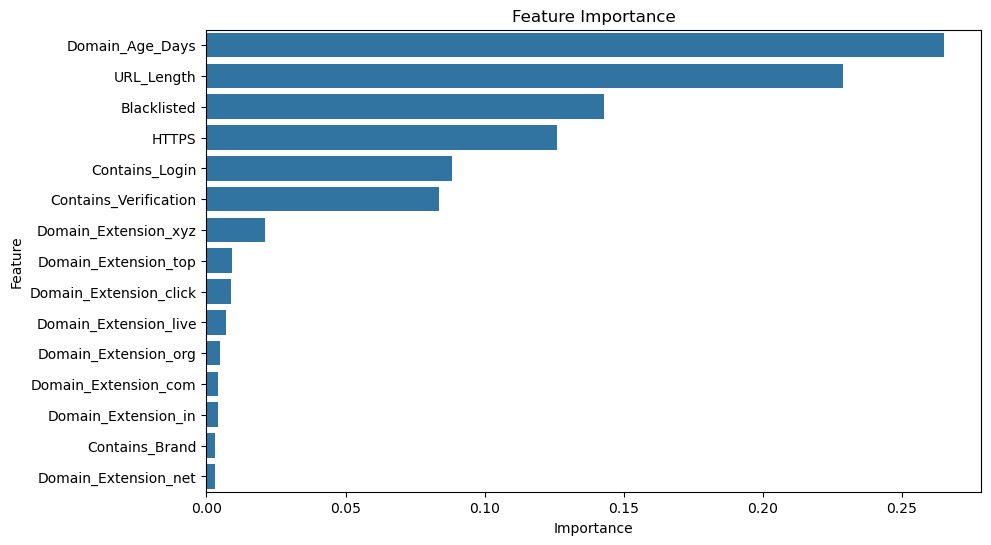

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [39]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [40]:
import shap

In [41]:
explainer = shap.TreeExplainer(best_rf)

In [43]:
shap_values = explainer.shap_values(x_test)

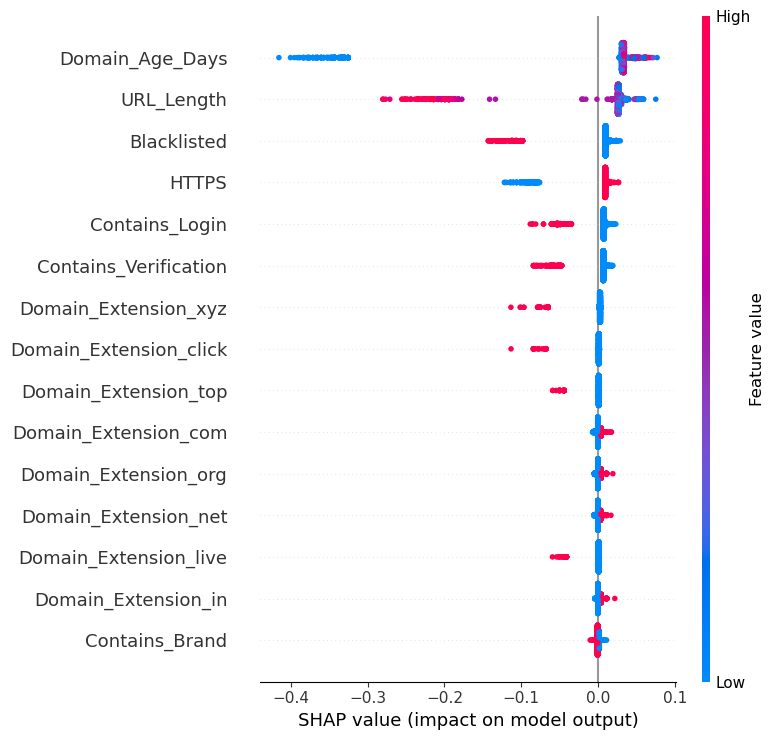

In [44]:
shap.summary_plot(shap_values[:,:,1],x_test)

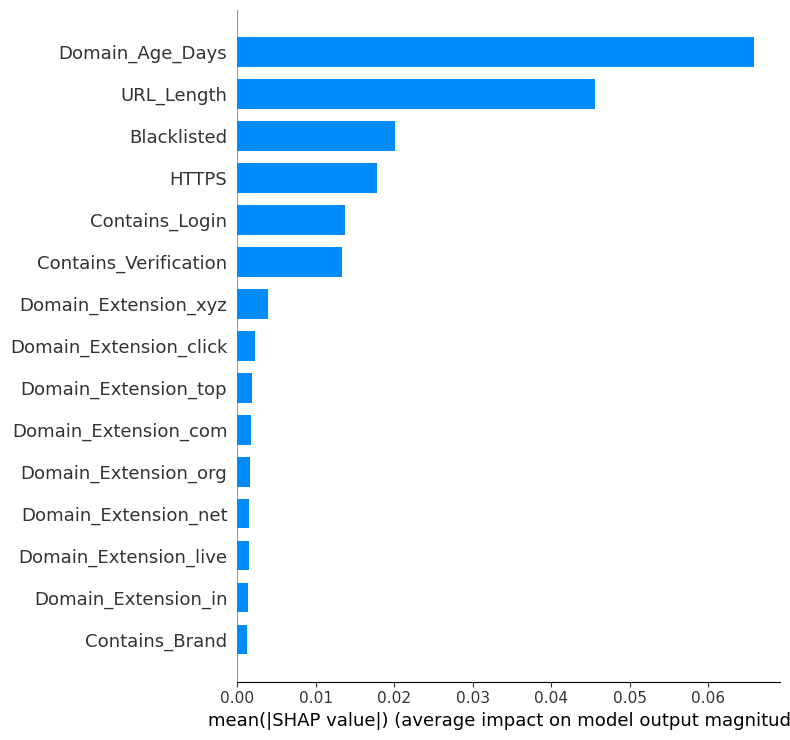

In [45]:
shap.summary_plot(shap_values[:,:,1],x_test,plot_type="bar")

In [47]:
transaction = x_test.iloc[[0]]
transaction

,URL_Length,HTTPS,Contains_Login,Contains_Verification,Contains_Brand,Domain_Age_Days,Blacklisted,Domain_Extension_click,Domain_Extension_com,Domain_Extension_in,Domain_Extension_live,Domain_Extension_net,Domain_Extension_org,Domain_Extension_top,Domain_Extension_xyz
2766,68,1,0,0,0,701,0,False,True,False,False,False,False,False,False


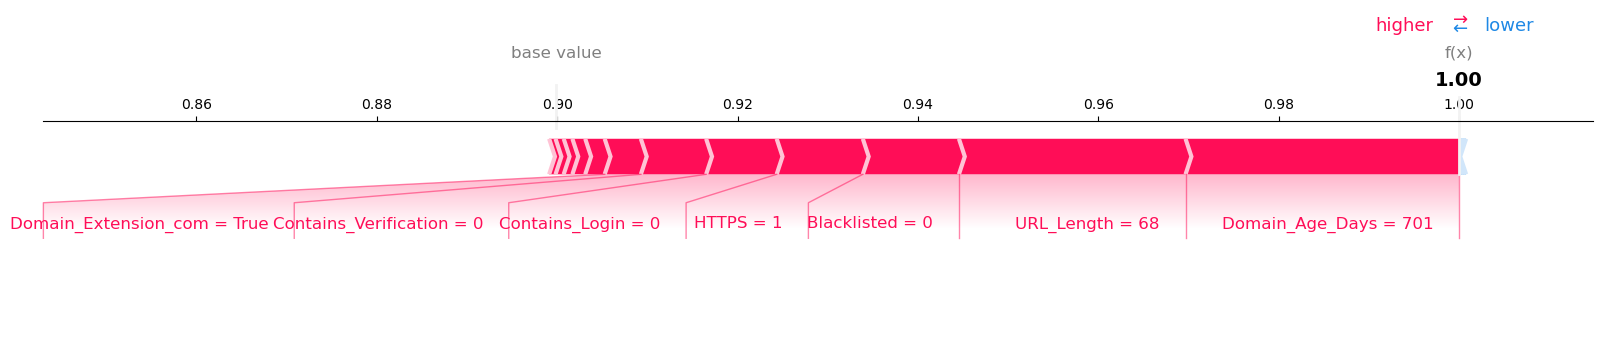

In [48]:
shap.force_plot(explainer.expected_value[1],shap_values[0,:,1],transaction,matplotlib=True)

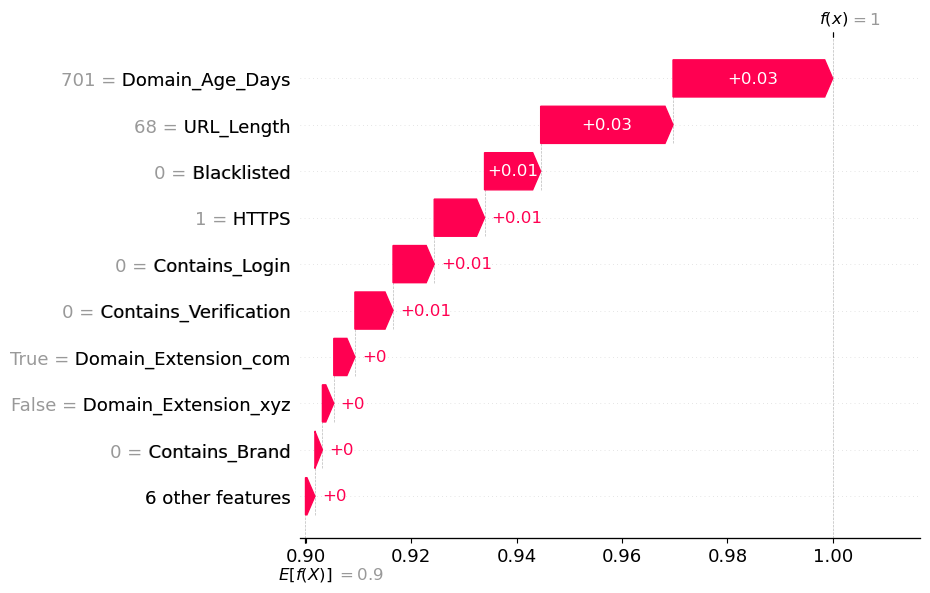

In [49]:
shap.plots.waterfall(shap.Explanation(values=shap_values[0,:,1],base_values=explainer.expected_value[1],data=transaction.iloc[0],feature_names=X_test.columns))

In [50]:
joblib.dump(best_rf,'qr_fraud_detection_model.pkl')
print("Model Saved Successfully")

Model Saved Successfully


In [51]:
loaded_model = joblib.load('qr_fraud_detection_model.pkl')

In [53]:
sample = X_test.iloc[[0]]

prediction = best_rf.predict(sample)

probability = best_rf.predict_proba(sample)

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [1]
Probability: [[8.88932709e-06 9.99991111e-01]]
